# Multi-Head Attention Visualized

In [2]:
import sys
sys.path.append('.')
import torch
import tiktoken
import matplotlib.pyplot as plt
from previous_chapters import load_gpt2_model

# GPT-2 Small (124M) 설정
GPT_CONFIG_SMALL = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.0,
    "qkv_bias": True
}

sentence_a = "The artist painted the portrait of a woman with a brush"

# 모델 로드
model = load_gpt2_model("gpt2-small-124M.pth", GPT_CONFIG_SMALL)
model.eval()

# 토크나이저
tokenizer = tiktoken.get_encoding("gpt2")

# 토큰화 및 attention weights 수집 (forward hook)
token_ids = tokenizer.encode(sentence_a)
tokens = [tokenizer.decode([t]) for t in token_ids]
input_tensor = torch.tensor([token_ids])

all_attentions = []

def make_hook():
    def hook_fn(module, input, output):
        x = input[0]
        b, num_tokens, _ = x.shape
        keys = module.W_key(x)
        queries = module.W_query(x)
        keys = keys.view(b, num_tokens, module.num_heads, module.head_dim).transpose(1, 2)
        queries = queries.view(b, num_tokens, module.num_heads, module.head_dim).transpose(1, 2)
        attn_scores = queries @ keys.transpose(2, 3)
        mask_bool = module.mask.bool()[:num_tokens, :num_tokens]
        attn_scores = attn_scores.masked_fill(mask_bool, -torch.inf)
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        all_attentions.append(attn_weights.detach())
    return hook_fn

hooks = [block.att.register_forward_hook(make_hook()) for block in model.trf_blocks]
with torch.no_grad():
    model(input_tensor)
for hook in hooks:
    hook.remove()

print(f"레이어 수: {len(all_attentions)}, 헤드 수: {all_attentions[0].shape[1]}, 토큰: {tokens}")

C:\workspace\llm_hands_on\previous_chapters.py:472: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


레이어 수: 12, 헤드 수: 12, 토큰: ['The', ' artist', ' painted', ' the', ' portrait', ' of', ' a', ' woman', ' with', ' a', ' brush']


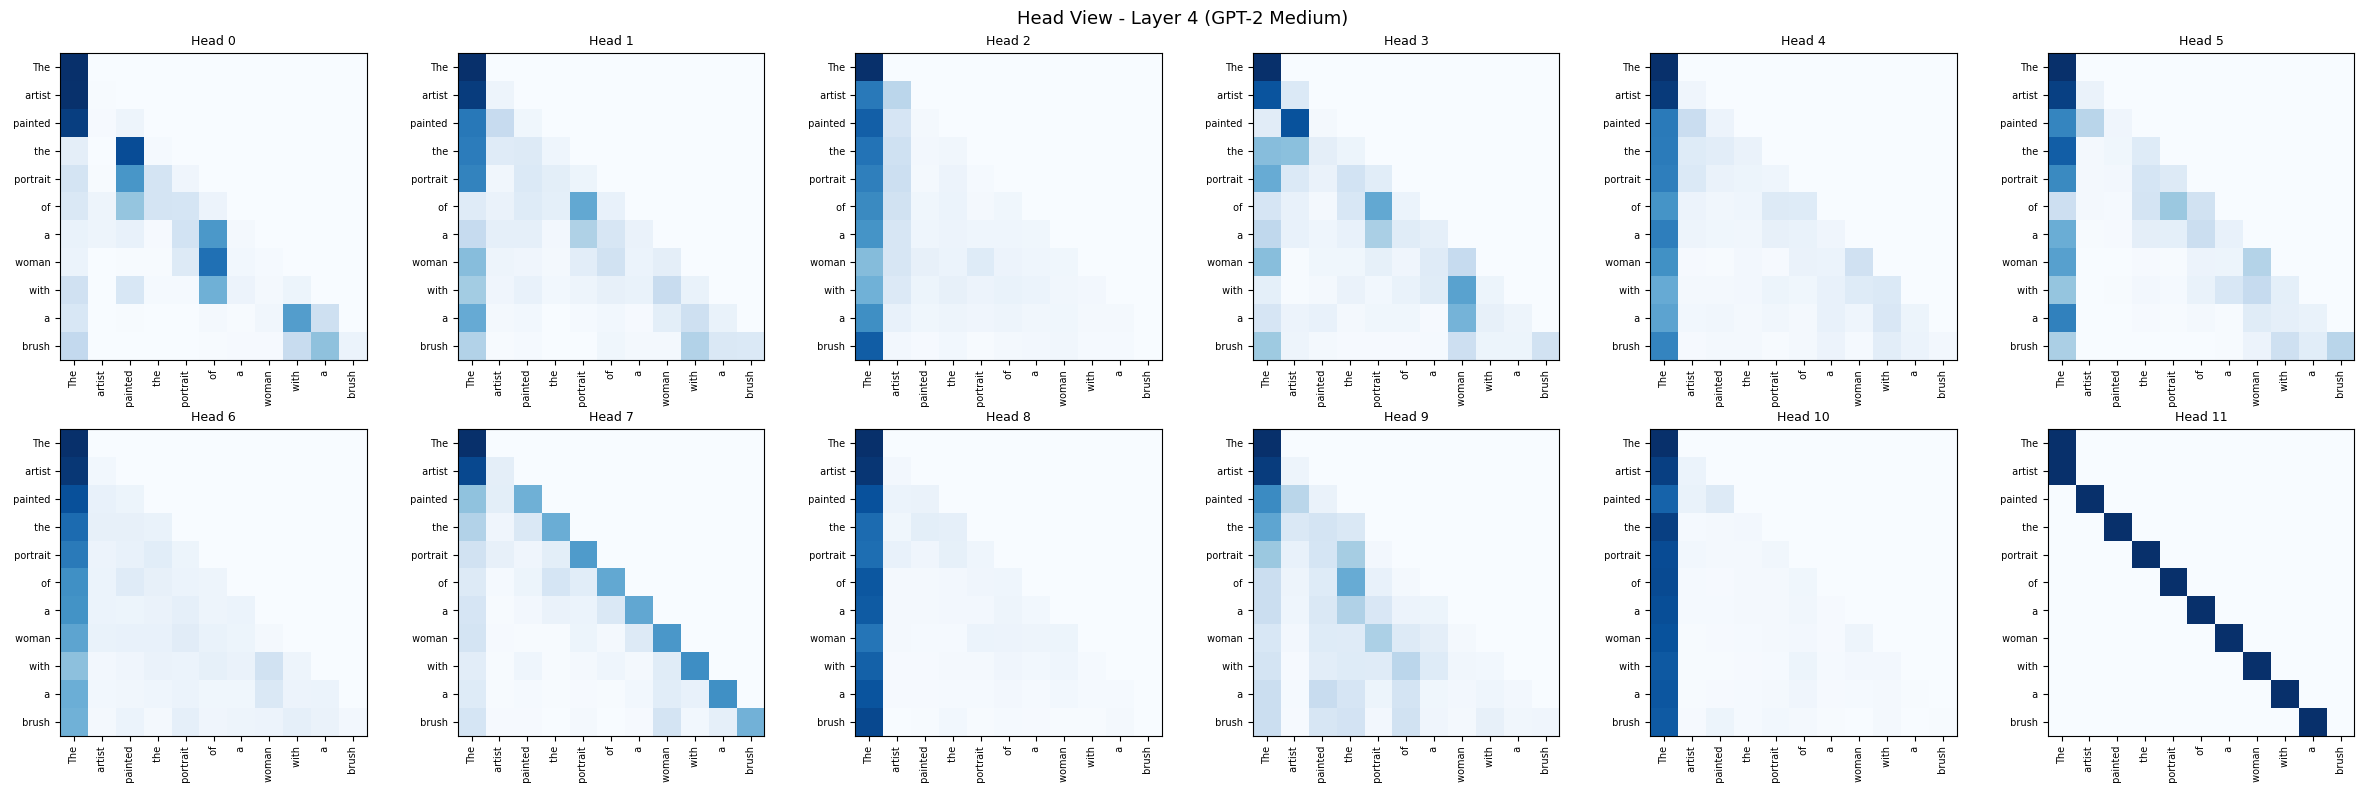

In [3]:
# head_view 대체: layer=4의 모든 헤드 attention 히트맵
layer_idx = 4
num_heads = all_attentions[layer_idx].shape[1]  # 16

fig, axes = plt.subplots(2, num_heads // 2, figsize=(24, 8))
axes = axes.flatten()

for head_idx in range(num_heads):
    attn = all_attentions[layer_idx][0, head_idx].numpy()
    axes[head_idx].imshow(attn, cmap="Blues")
    axes[head_idx].set_title(f"Head {head_idx}", fontsize=9)
    axes[head_idx].set_xticks(range(len(tokens)))
    axes[head_idx].set_xticklabels(tokens, rotation=90, fontsize=7)
    axes[head_idx].set_yticks(range(len(tokens)))
    axes[head_idx].set_yticklabels(tokens, fontsize=7)

plt.suptitle(f"Head View - Layer {layer_idx} (GPT-2 Medium)", fontsize=13)
plt.tight_layout()
plt.show()

In [4]:
import io
import numpy as np
import ipywidgets as widgets
from IPython.display import display

previous_ui = globals().get("_attention_ui")
if previous_ui is not None:
    previous_ui["controls"].close()
    previous_ui["layer_w"].close()
    previous_ui["head_w"].close()
    previous_ui["plot_widget"].close()

plot_widget = widgets.Image(format="png")

def plot_attention_lines(change=None):
    layer_idx = layer_w.value
    head_idx = head_w.value
    attn = all_attentions[layer_idx][0, head_idx].numpy()
    n = len(tokens)

    with plt.ioff():
        fig, ax = plt.subplots(figsize=(8, max(6, n * 0.45)))

    fig.patch.set_facecolor("#000000")
    ax.set_facecolor("#000000")

    y_pos = np.linspace(0.95, 0.05, n)
    x_left, x_right = 0.2, 0.8

    for i in range(n):
        for j in range(n):
            w = float(attn[i, j])
            if w > 0.005:
                ax.plot([x_left, x_right], [y_pos[i], y_pos[j]],
                        color="#4A90D9", alpha=min(w * 2, 1.0), linewidth=1.2)

    for i, tok in enumerate(tokens):
        ax.text(x_left - 0.01, y_pos[i], tok, ha="right", va="center",
                color="white", fontsize=10, fontfamily="monospace")
        ax.text(x_right + 0.01, y_pos[i], tok, ha="left", va="center",
                color="white", fontsize=10, fontfamily="monospace")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.set_title(f"Layer: {layer_idx}  Head: {head_idx}",
                 color="white", fontsize=12, pad=10)
    fig.tight_layout()

    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", facecolor=fig.get_facecolor(), bbox_inches="tight")
    plot_widget.value = buffer.getvalue()
    buffer.close()
    plt.close(fig)

layer_w = widgets.Dropdown(
    options=list(range(len(all_attentions))), value=4, description="Layer:")
head_w = widgets.Dropdown(
    options=list(range(all_attentions[0].shape[1])), value=3, description="Head:")
controls = widgets.HBox([layer_w, head_w])

layer_w.observe(plot_attention_lines, names="value")
head_w.observe(plot_attention_lines, names="value")

display(controls)
display(plot_widget)
globals()["_attention_ui"] = {
    "layer_w": layer_w,
    "head_w": head_w,
    "controls": controls,
    "plot_widget": plot_widget,
}
plot_attention_lines()  # ?? ???


Image(value=b'')